# 📊 Count-Min Sketch — Netflix EDA

**Conteo Probabilístico de Popularidad de Videos**  
Curso: Estructuras de Datos y Algoritmos | UTEC

---

## ¿Qué es Count-Min Sketch?

El **Count-Min Sketch** es una estructura de datos probabilística que estima la frecuencia de elementos en un flujo de datos usando **memoria sublineal**. Publicado por Cormode & Muthukrishnan en 2005.

### Cómo funciona

1. Se crea una matriz de `d × w` contadores (todos en 0)
2. Para **actualizar** un elemento, se calculan `d` posiciones hash y se incrementan los contadores correspondientes
3. Para **consultar** la frecuencia, se calculan los mismos `d` hashes y se retorna el **mínimo** de los contadores

El error garantizado es: `P(estimación > real + ε×N) < δ` donde `ε = e/w` y `δ = e^(-d)`

### Uso en Netflix

Contar exactamente cuántas veces se reproduce cada video de los millones en el catálogo requeriría un HashMap enorme. Con Count-Min Sketch:
- Usar ~100KB de memoria en lugar de ~10MB
- Procesar millones de eventos por segundo
- Error muy pequeño (< 1% con parámetros adecuados)

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/Guido-Silva/netflix-streaming-eda.git
    %cd netflix-streaming-eda
    PROJECT_ROOT = Path.cwd().resolve()
else:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

INFORME_DIR = PROJECT_ROOT / "informe"
INFORME_DIR.mkdir(parents=True, exist_ok=True)

print(f"Entorno configurado | PROJECT_ROOT={PROJECT_ROOT}")


Entorno configurado | PROJECT_ROOT=C:\Users\jsilvac\Documents\UTEC Maestria\2do ciclo\Estructuras de Datos y Algoritmos\Proyecto Final\netflix-streaming-eda


In [2]:
from src.count_min_sketch import CountMinSketch
print('✅ Módulo Count-Min Sketch importado')

✅ Módulo Count-Min Sketch importado


In [3]:
from src.count_min_sketch import demo
demo()

   DEMO: Count-Min Sketch - Plataforma Netflix

📺 Simulando reproducciones de videos:

📊 Estadísticas de la estructura:
  width: 500
  depth: 5
  celdas_totales: 2500
  total_actualizaciones: 4597
  elementos_unicos: 110
  error_estimado_max: e/500 = 2.718/500 ≈ 0.005436
  prob_error_max: e^(-5) ≈ 0.006741

🔍 Comparación: Conteo Real vs Estimado:
  Video                              Real   Estimado    Error
  ------------------------------------------------------------
  stranger_things_s4                  811        811       +0
  squid_game_s1                       720        720       +0
  la_casa_papel_s5                    508        508       +0
  the_crown_s5                        402        402       +0
  dark_s1                             192        192       +0
  lupin_s2                            170        170       +0
  narcos_s1                            96         96       +0
  black_mirror_s1                      96         96       +0
  mindhunter_s1               

In [4]:
# Experimento: Error de estimación vs (width, depth)
import random
import numpy as np

print('📊 Experimento: Error vs Parámetros del CMS')
print('=' * 60)

N_ELEMENTOS = 1000
N_UPDATES = 100000

# Generar conteos reales
elementos = [f'video_{i:04d}' for i in range(N_ELEMENTOS)]
# Popularidad con distribución Zipf
pesos = [1.0 / (i + 1) for i in range(N_ELEMENTOS)]
suma = sum(pesos)
pesos = [p / suma for p in pesos]

conteos_reales = {e: 0 for e in elementos}
random.seed(42)
for _ in range(N_UPDATES):
    elem = random.choices(elementos, weights=pesos)[0]
    conteos_reales[elem] += 1

widths = [100, 500, 1000, 2000]
depths = [3, 5, 7]

errores = np.zeros((len(depths), len(widths)))

for i, depth in enumerate(depths):
    for j, width in enumerate(widths):
        cms = CountMinSketch(width=width, depth=depth)
        
        # Insertar todos los datos
        random.seed(42)
        for _ in range(N_UPDATES):
            elem = random.choices(elementos, weights=pesos)[0]
            cms.update(elem)
        
        # Calcular error relativo promedio
        errores_individuales = []
        for elem in elementos[:100]:  # Revisar primeros 100
            real = conteos_reales[elem]
            estimado = cms.query(elem)
            if real > 0:
                error_rel = (estimado - real) / real
                errores_individuales.append(error_rel)
        
        errores[i][j] = np.mean(errores_individuales) * 100  # En porcentaje
        print(f'  width={width:>5}, depth={depth}: error_relativo_promedio={errores[i][j]:.2f}%')

📊 Experimento: Error vs Parámetros del CMS
  width=  100, depth=3: error_relativo_promedio=135.60%
  width=  500, depth=3: error_relativo_promedio=9.78%
  width= 1000, depth=3: error_relativo_promedio=3.12%
  width= 2000, depth=3: error_relativo_promedio=0.21%
  width=  100, depth=5: error_relativo_promedio=102.05%
  width=  500, depth=5: error_relativo_promedio=4.92%
  width= 1000, depth=5: error_relativo_promedio=0.50%
  width= 2000, depth=5: error_relativo_promedio=0.01%
  width=  100, depth=7: error_relativo_promedio=85.62%
  width=  500, depth=7: error_relativo_promedio=2.93%
  width= 1000, depth=7: error_relativo_promedio=0.22%
  width= 2000, depth=7: error_relativo_promedio=0.00%


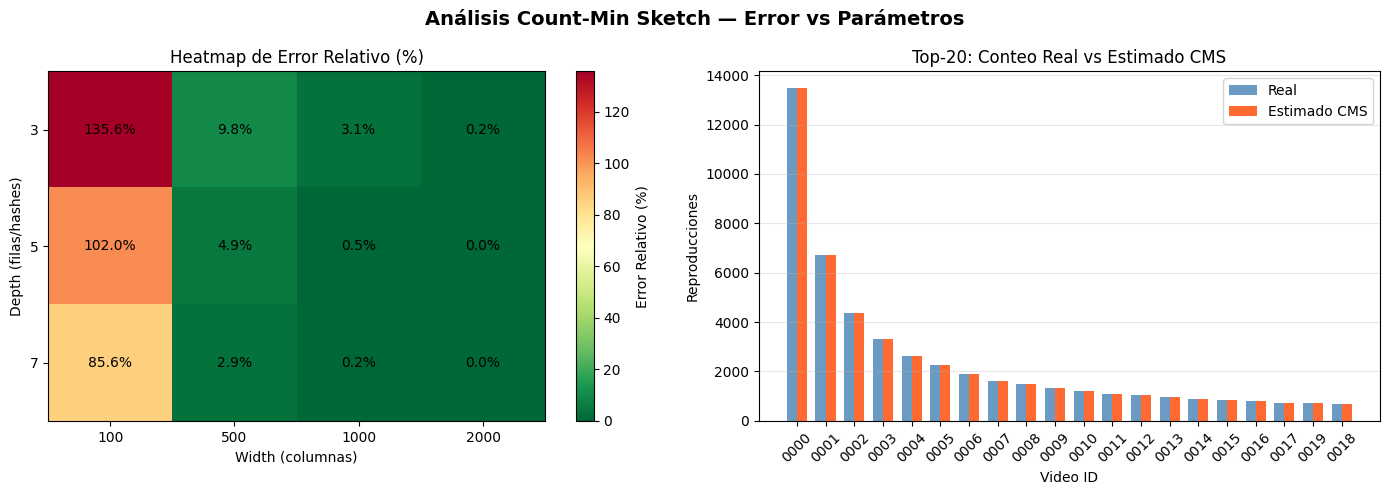

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de error
im = axes[0].imshow(errores, cmap='RdYlGn_r', aspect='auto')
axes[0].set_xticks(range(len(widths)))
axes[0].set_xticklabels(widths)
axes[0].set_yticks(range(len(depths)))
axes[0].set_yticklabels(depths)
axes[0].set_xlabel('Width (columnas)')
axes[0].set_ylabel('Depth (filas/hashes)')
axes[0].set_title('Heatmap de Error Relativo (%)')
plt.colorbar(im, ax=axes[0], label='Error Relativo (%)')

for i in range(len(depths)):
    for j in range(len(widths)):
        axes[0].text(j, i, f'{errores[i][j]:.1f}%', ha='center', va='center', 
                    color='black', fontsize=10)

# Comparación real vs estimado para top-20 videos
cms_bueno = CountMinSketch(width=2000, depth=7)
random.seed(42)
for _ in range(N_UPDATES):
    elem = random.choices(elementos, weights=pesos)[0]
    cms_bueno.update(elem)

top20_reales = sorted(conteos_reales.items(), key=lambda x: -x[1])[:20]
nombres = [x[0][-4:] for x in top20_reales]
reales = [x[1] for x in top20_reales]
estimados = [cms_bueno.query(x[0]) for x in top20_reales]

x = range(len(nombres))
width = 0.35
axes[1].bar([xi - width/2 for xi in x], reales, width, label='Real', color='steelblue', alpha=0.8)
axes[1].bar([xi + width/2 for xi in x], estimados, width, label='Estimado CMS', color='orangered', alpha=0.8)
axes[1].set_xlabel('Video ID')
axes[1].set_ylabel('Reproducciones')
axes[1].set_title('Top-20: Conteo Real vs Estimado CMS')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(nombres, rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Análisis Count-Min Sketch — Error vs Parámetros', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(INFORME_DIR / 'cms_error_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## 📊 Análisis de Complejidad y Memoria

| Operación | Complejidad Temporal | Complejidad Espacial |
|-----------|---------------------|---------------------|
| `update(item, count)` | **O(d)** | O(1) adicional |
| `query(item)` | **O(d)** | O(1) adicional |
| `top_k(k)` | **O(n log k)** | O(k) |
| Espacio total | — | **O(w × d)** |

### Comparativa de Memoria

| Estructura | N elementos | Memoria | Precisión |
|-----------|------------|---------|----------|
| HashMap exacto | 1,000,000 | ~50 MB | 100% exacto |
| **Count-Min Sketch** (w=2000, d=7) | 1,000,000 | **~56 KB** | ~99% (error < 1%) |

**¡Reducción de ~1000x en memoria con <1% de error!**

### Garantías Teóricas (con w=2000, d=7)

- **Error máximo**: ε = e/w = 2.718/2000 ≈ 0.14% del total N
- **Probabilidad de superar error**: δ = e^(-d) = e^(-7) ≈ 0.09%
- **Nunca subestima**: La estimación siempre es ≥ al valor real